![](https://media.licdn.com/dms/image/v2/D5612AQG8vFmWheQxCw/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1706388877624?e=1751500800&v=beta&t=bqNY2CxeA7-s6LFCilc9m6ZMZ5rr1ez1YW0Gzd0feG8)

# RFM Analizi Nedir? 

Müşteri sadakati, bir markanın uzun vadeli başarısının anahtarıdır. Markalar, yeni müşteriler kazanmak ve mevcut müşterilerini elde tutmak için önemli yatırımlar yapıyor. 

Müşteri sadakatini artırmaya yönelik stratejiler geliştirmek, uzun vadede markaların daha verimli ve sürdürülebilir büyüme sağlamasına yardımcı olabilir.

**Müşterimizi nasıl geri kazanabiliriz?  
Hangi müşterilerimize nasıl strateji geliştirmeliyiz?**

**RFM ANALİZİNE NE ZAMAN İHTİYAÇ DUYULUR?**  

RFM analizinin yapılması, müşterilerin sadakat düzeylerini anlamak ve Churn riski taşıyanları belirleyerek, segment bazlı pazarlama stratejileri geliştirmek için oldukça önemlidir.

Müşteriler, satın alma alışkanlıkları ve davranışlarına göre segmentlere ayrılır. RFM Analizi uygulamasıyla şirketler pazarlama stratejilerini doğru bir şekilde uyarlayabilir, mesajların ve tekliflerin her segmente göre kişiselleştirilmesini sağlayabilir.

**Recency:**  
*Müşteri yakın zamanda alışveriş yaptı mı?*  
Müşterinin en son satın alma yaptığını gösteren metriktir. Düşük bir Recency değeri, yakın zamanda satın alma işlemini gösterir.  
**Frequency:**  
*Müşteri alışveriş yapma sıklığı nedir?*  
Müşterinin ne sıklıkta alışveriş yaptığını gösterir. Müşterinin işlem sayısı ne kadar yüksekse potansiyeli yüksektir.  
**Monetary:**  
*Müşteri alışverişte ne kadar para harcadı?*  
Markanın satın alma sonucunda müşterilerden elde ettiği parasal değerdir.

# Veri Seti Bilgileri

Veri seti, 01/12/2010 ile 09/12/2011 tarihleri arasında İngiltere merkezli ve kayıtlı, mağaza dışı bir online perakende kuruluşu tarafından gerçekleştirilen işlemleri kapsar.

Veri setindeki değişkenler:

*   InvoiceNo: Her işlem/fatura için benzersiz kimlik numarası
*   StockCode: Her ürün için benzersiz ürün kodu
*   Description: Ürün açıklaması
*   Quantity: Her işlemde satın alınan ürün adedi
*   InvoiceDate: İşlemin gerçekleştiği tarih ve saat
*   UnitPrice: Ürünün birim fiyatı
*   CustomerID: Müşteri numarası
*   Country: Müşterinin ikamet ettiği ülke
  

In [1]:
# Kütüphaneleri import edelim: 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import numpy as np
import datetime as dt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format',lambda x: '%.2f' % x)

/kaggle/input/ecommerce-data/data.csv


In [2]:
# Veri setimizi analiz etmeye başlayalım:
df_=pd.read_csv('/kaggle/input/ecommerce-data/data.csv', encoding="ISO-8859-1")
df=df_.copy()
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


In [3]:
# Veri setinin satır-sütun bilgisine bakalım (satır,değişken)
df.shape

(541909, 8)

In [4]:
# Veri setindeki eksik degerlerin olup olmadığına bakılır.
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Değişken sayısını, boş değer olup olmadığını, tip bilgisini gösterir
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# Tarih içeren değişkenlerin, tipini date'e çeviriyoruz
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [7]:
# CustomerID belli değilse ve müşteri özelinde segmentasyon çalışması yapılacağı için ölçülebilirlik değeri taşımıyor
df.dropna(subset=['CustomerID','Description'], inplace=True)

# Yinelenen satırlar kaldırılır
#inplace=True değişken ataması yapılmadan değişikliğin kalıcı olması sağlanır
df.drop_duplicates(inplace=True)

# Keşifsel Veri Analizi (Exploratory Data Analysis – EDA)

In [8]:
# Ürünlerin toplam kazancı - yeni sütun oluşturulur
df['TotalPrice']=df['Quantity']*df['UnitPrice']

In [9]:
#Recency değeri için müşterinin en son alışveriş yaptığı tarihten geçen zamanı hesaplamalıyız.
#Verisetindeki girilen son tarihi bakalım
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [10]:
# Eski veri seti olduğu için Recency değerinin doğru olmayacak şekilde büyük çıkmasına neden olabilir.
# 2 gün sonrasını analiz tarihi olarak (today date) atayalım.
today_date = dt.datetime(2011, 12, 11)

# RFM Metriklerinin Hesaplanması

Recency, Frequency, Monetary

**Recency(Müşteri Yeniliği):** Analizin Yapıldığı Tarih - Son Satın Alma Tarihi  
**Frequency:** Toplam Satın Alma Sayısı  
**Monetary:** Toplam Harcanan Para

In [11]:
rfm=df.groupby('CustomerID').agg({'InvoiceDate':lambda InvoiceDate:(today_date-InvoiceDate.max()).days,
                                   'InvoiceNo': lambda Invoice:Invoice.nunique(),
                                   'TotalPrice':lambda TotalPrice: TotalPrice.sum()})
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.00,326,2,0.00
12347.00,3,7,4310.00
12348.00,76,4,1797.24
12349.00,19,1,1757.55
12350.00,311,1,334.40


In [12]:
# Liste aracılıgı ile RFM metrikleri sütun isimlerini değiştirelim
rfm.columns=['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.00,326,2,0.00
12347.00,3,7,4310.00
12348.00,76,4,1797.24
12349.00,19,1,1757.55
12350.00,311,1,334.40


Recency değeri 3 olan ( 3 gün önce alışveriş yapan müşteri) ile recency değeri 326 olan ( 326 gün önce alışveriş yapan müşteri) müşteri markaya göre daha değerlidir.

**Metrikleri incelediğimizde sık alışveriş yapan mı?  
Yakın zamanda alışveriş yapan mı?  
Daha fazla para harcayan mı marka için önemlidir?**

Standartlaştırma işlemi yapılarak metrikleri birbiriyle kıyaslanabilir formata getirebiliriz. RFM Metriklerini aralarında kıyaslama yapabileceğimiz, segmentlere kolaylıkla ayırabileceğimiz şekilde RFM Skorlarına çevireceğiz.

# RFM Skorlarının Oluşturulması

In [13]:
rfm['recency_score']=pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])

# olusturulan degerlerde unique deger alması icin. rank(method='first')=> ilk gordugunu ilk sınıfa atama
rfm['frequency_score']=pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])

#etiketleri sıralı yaparak küçük gördüğüne küçük score verilecek şekilde ayarlandı
rfm['monetary_score']=pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score
CustomerID,,,,,,
12346.00,326,2,0.00,1,2,1
12347.00,3,7,4310.00,5,4,5
12348.00,76,4,1797.24,2,3,4
12349.00,19,1,1757.55,4,1,4
12350.00,311,1,334.40,1,1,2


**qcut() (degisken,bolme oranı,label etiketleri)**  
qcut fonksiyonu yardımıyla eşit bölmelere ayırarak metrikleri 1 ve 5 arasında puanlandıracağız.  
**Recency**  
1, en yakın zamanda alışveriş yapan müşterileri (en düşük Recency değeri) temsil ederken,  
5, en uzun süre önce alışveriş yapan müşterileri (en yüksek Recency değeri) temsil eder.  
**Frequency**  
5, en sık alışveriş yapan müşterileri,  
1, en az alışveriş yapan müşterileri temsil eder.  
**Monetary**  
5, en yüksek harcama yapan müşterileri,  
1, en az harcama yapan müşterileri temsil eder.  

**NOT:** Segmentler oluşturulurken e-ticaret sektörüyle ilgili olarak Monetary değeri hesaba katılmamaktadır. Müşterinin parasal getirisi bu veri seti için ön planda değildir.(Sektöre bağlı olarak)
Öncelik Recency ve Frequency değeri yüksek sadık müşteriler kazanmaktır. Sadık müşteriler kazandıktan sonra monetary değeri artış gösterecektir.

In [14]:
rfm['RF_SCORE']=(rfm['recency_score'].astype(str)+ rfm['frequency_score'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_SCORE
CustomerID,,,,,,,
12346.00,326,2,0.00,1,2,1,12
12347.00,3,7,4310.00,5,4,5,54
12348.00,76,4,1797.24,2,3,4,23
12349.00,19,1,1757.55,4,1,4,41
12350.00,311,1,334.40,1,1,2,11


# Müşteri Segmentasyonu

![](https://blog.gxsoftware.com/hubfs/RFM%20Model%20results.svg)

In [15]:
map_segment={
    r'[1-2][1-2]':'hibernating',
    r'[1-2][3-4]':'at_risk',
    r'[1-2]5':'cant_loose_them',
    r'3[1-2]':'about_to_sleep',
    r'33':'need_attention',
    r'[3-4][4-5]':'loyal_customers',
    r'41':'promising',
    r'51':'new customers',
    r'[4-5][2-3]':'potential_loyalists',
    r'5[4-5]':'champions'
}

# regex ifadesi ile skorlar birleşir
rfm['RF_SEGMENT']=rfm['RF_SCORE'].replace(map_segment,regex=True)
rfm.head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_SCORE,RF_SEGMENT
CustomerID,,,,,,,,
12346.00,326,2,0.00,1,2,1,12,hibernating
12347.00,3,7,4310.00,5,4,5,54,champions
12348.00,76,4,1797.24,2,3,4,23,at_risk
12349.00,19,1,1757.55,4,1,4,41,promising
12350.00,311,1,334.40,1,1,2,11,hibernating


In [16]:
# need_attention ilgi görmezse önce Uyku sonra Churn olma ihtimali var.
rfm[rfm['RF_SEGMENT']=='need_attention'].head()

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RF_SCORE,RF_SEGMENT
CustomerID,,,,,,,,
12360.00,53,3,2662.06,3,3,5,33,need_attention
12370.00,52,4,3541.94,3,3,5,33,need_attention
12372.00,72,3,1298.04,3,3,4,33,need_attention
12546.00,47,3,1141.50,3,3,4,33,need_attention
12759.00,53,3,1531.44,3,3,4,33,need_attention


**CHAMPIONS** - RF Scores: 55 - 54  
Markaya bağlı ve sadık müşteri grubudur.  
Sık sık satın alma ve en çok harcamayı yaparlar.  
Marka elçileri olarak hareket ederler.  
*Pazarlama Stratejisi:*
* Özel fırsatlar, toplu indirimler, yeni ürün denemeleri, sadakat programınıza üyelik sunulabilir.
* Yeni bir ürününüz olduğunda, bunu ilk öğrenen müşteriler onlar olmalıdır.
    
**LOYAL CUSTOMERS** - RF Scores: 34 - 35 - 44 - 45   
Sık satın alma ve harcama değeri yüksek segment sınıfıdır.
Tekliflere karşı hassastırlar.
Şampiyonlara dönüşme potansiyelleri vardır.  
*Pazarlama Stratejisi:*
* Onlara yüksek değerli, kişiselleştirilmiş ürün önerileri sunulabilir.
* Onlardan yorum istenebilir.
* Sadakat oluşturulmalıdır.

**NEW CUSTOMERS** - RF Scores: 51  
Yakın zamanda alışveriş yapmış ama sık satın alma yapmayan müşteri grubudur.  
*Pazarlama Stratejisi:*
* Onları katılım süreçlerinde desteklenebilir.  
* Memnuniyetlerini sağlanabilir.  
* Sadakat oluşturmaya başlanabilir.  

**CAN'T LOSE THEM** - RF Scores: 15 - 25  
Yüksek harcama ve sık alışveriş yapmaya yatkın fakat son zamanlarda alışveriş yapmayan müşteri grubudur.  
Değerli müşterilerdir.  
*Pazarlama Stratejisi:*
* Yeni ürün lansmanlarıyla geri kazandırılmalıdır.
* Rakiplerinizin onları almasına izin verilmemelidir.
* Özel teklifler içeren kişisel e-postalar gönderilebilir.
* Onlarla konuşup geri bildirim istenebilir.


**HIBERNATING**  
*Pazarlama Stratejisi:*
* Daha düşük puan alan gruplara markanız hatırlatılmalıdır.
* Onlara daha önce görüntülenen veya istek listesinde yer alan ürünleri gönderin.
* Bir noktada şirkette değer gördüler nedenini hatırlamalarını sağlamaya çalışın.

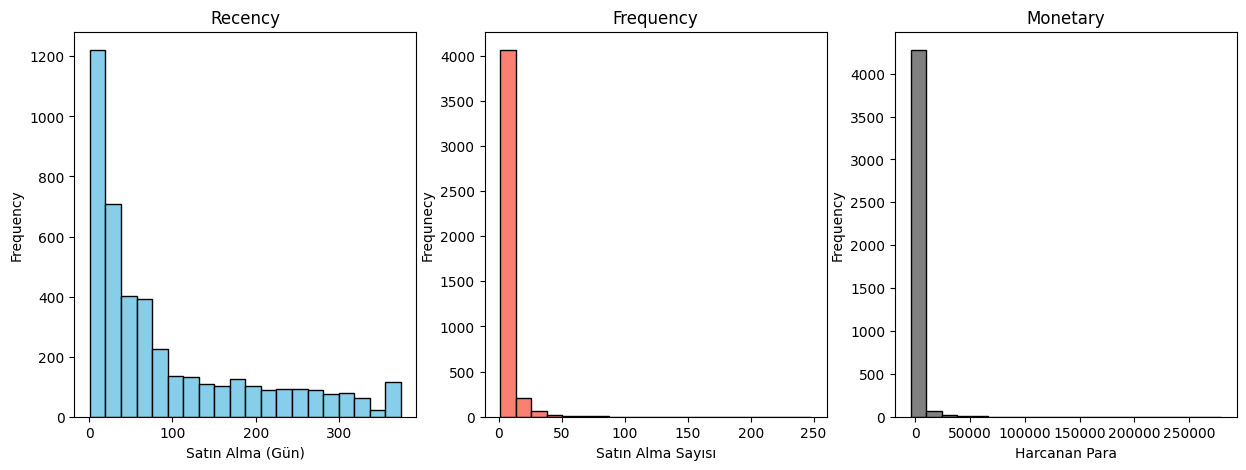

In [17]:
# RFM Değeri

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(rfm['Recency'], bins = 20, color = 'skyblue', edgecolor = 'black')
plt.xlabel('Satın Alma (Gün)')
plt.ylabel('Frequency')
plt.title('Recency')

plt.subplot(1, 3, 2)
plt.hist(rfm['Frequency'], bins = 20, color = 'salmon', edgecolor = 'black')
plt.xlabel('Satın Alma Sayısı')
plt.ylabel('Frequnecy')
plt.title('Frequency')

plt.subplot(1, 3, 3)
plt.hist(rfm['Monetary'], bins = 20, color = 'gray', edgecolor = 'black')
plt.title('Monetary')
plt.xlabel('Harcanan Para')
plt.ylabel('Frequency')

plt.show()

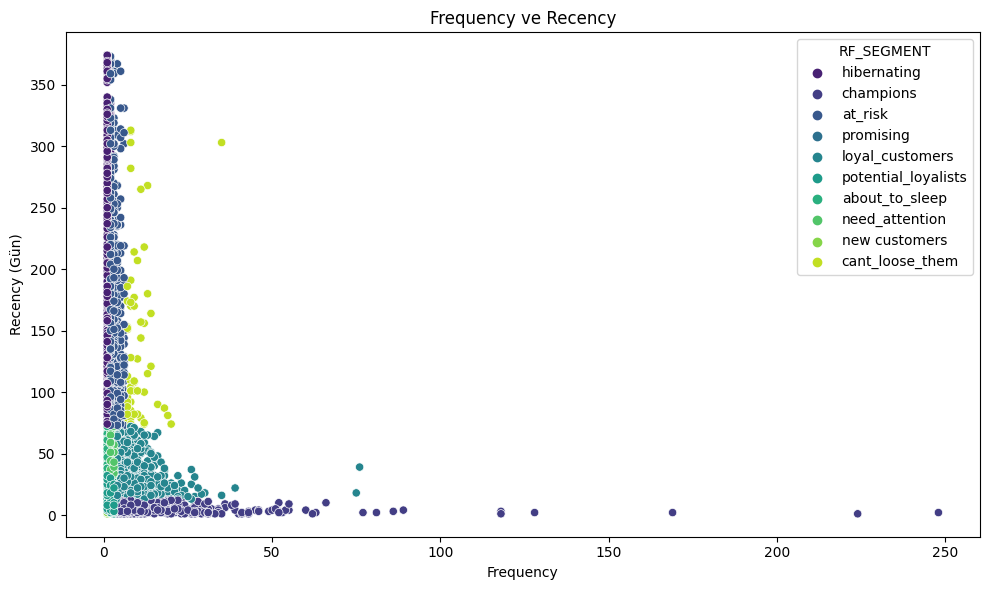

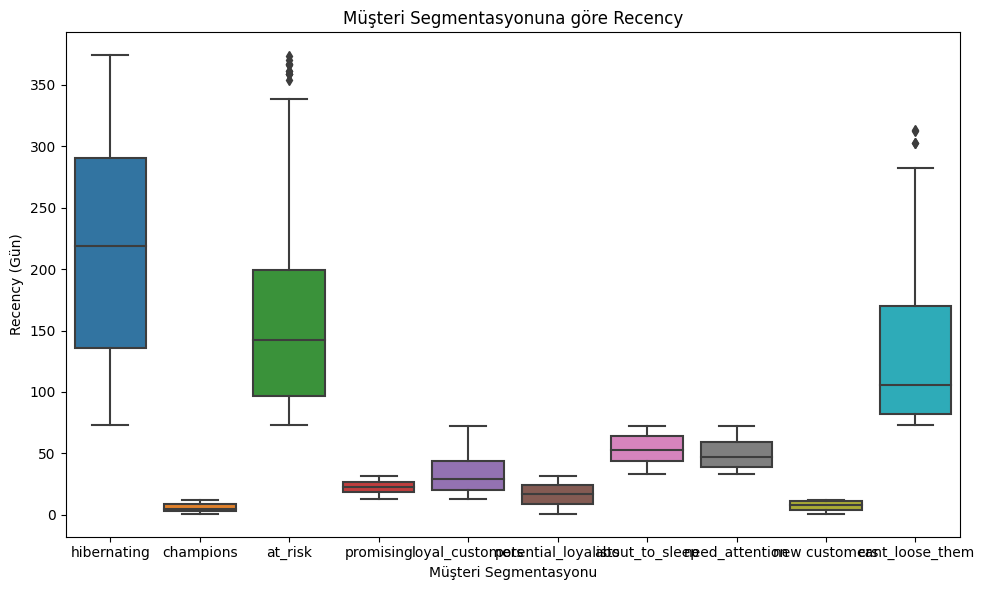

In [18]:
# RFM Metriklerinin Görselleştirilmesi

plt.figure(figsize=(10,6))

sns.scatterplot(x = 'Frequency', y='Recency', hue = 'RF_SEGMENT', data = rfm, palette='viridis')
plt.title('Frequency ve Recency')
plt.xlabel('Frequency')
plt.ylabel('Recency (Gün)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='RF_SEGMENT', y='Recency', data=rfm)
plt.title('Müşteri Segmentasyonuna göre Recency')
plt.xlabel('Müşteri Segmentasyonu')
plt.ylabel('Recency (Gün)')
plt.tight_layout()
plt.show()

In [19]:
rfm[['RF_SEGMENT','Recency','Frequency','Monetary']].groupby('RF_SEGMENT').agg({'mean','count'})

Recency       Frequency       Monetary      
                       mean count      mean count     mean count
RF_SEGMENT                                                      
about_to_sleep        53.05   369      1.29   369   432.48   369
at_risk              158.65   603      3.31   603   947.91   603
cant_loose_them      134.09    68      9.82    68  2373.60    68
champions              6.08   665     14.59   665  6496.80   665
hibernating          218.22  1053      1.20  1053   374.89  1053
loyal_customers       33.29   795      7.99   795  2697.41   795
need_attention        49.73   190      2.64   190   784.82   190
new customers          7.24    42      1.00    42   375.26    42
potential_loyalists   16.57   490      2.22   490   678.30   490
promising             23.10    97      1.00    97   300.26    97

*Mean Değerleri:*  

> Düşük bir Recency ortalaması, o segmentin müşterilerinin yakın zamanda alışveriş yaptığını,  
> Yüksek bir ortalama Frequency, segmentin müşterilerinin sıkça alışveriş yaptığını,  
> Yüksek bir ortalama Monetary, o segmentin müşterilerinin daha fazla harcama yaptığını gösterir.
  

*Count Değerleri:*  
> Her segmentteki müşteri sayısını belirtir. Segmentin ne kadar büyük veya küçük olduğunu anlamanızı sağlar. Eğer bir segmentte müşteri sayısı çok fazlaysa, o segment için daha fazla pazarlama stratejisi uygulanabilir. Küçük segmentler ise özel bir yaklaşım gerektirebilir.

# Sonuç

Pazarlamanın amacı, müşterinin ihtiyaç ve beklentilerini önceden anlayarak onlara en uygun şekilde ulaşmaktır. Bu sürecin temelinde, istenmeyen tekliflerde bulunmadan önce müşterinin neye değer verdiğini doğru analiz etmek yer alır. RFM analizi, müşterilerin eğilimlerini ve beklentilerini ortaya koyarak, onlara daha etkili ve hedefe yönelik pazarlama yapmayı mümkün kılar. Hedef kitle segmentleri esnektir. Bu, müşterilerin dinamik olduğu ve bir kategoriden diğerine geçebileceği anlamına gelir.


> Beğendiyseniz UPVOTE yapmayı unutmayın.
> 
>
> https://www.linkedin.com/in/selen-kaptanoğlu-30290415a/ 
> https://github.com/selenkaptanoglu   

